In [5]:
# imports
import matplotlib.pyplot as plt
import xarray as xr
from pythia_datasets import DATASETS

In [6]:
filepath = DATASETS.fetch("CESM2_sst_data.nc")
ds = xr.open_dataset(filepath)
ds

c:\Users\AKHTAR HUSSAIN\anaconda3\envs\climate\Lib\site-packages\xarray\conventions.py:205: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 47MB
Dimensions:    (time: 180, d2: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 3kB ...
    lat_bnds   (lat, d2) float64 3kB ...
    lon_bnds   (lon, d2) float64 6kB ...
    tos        (time, lat, lon) float32 47MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

In [7]:
#Resampling Data
# resample from a monthly to an annual frequency
tos_yearly = ds.tos.resample(time="AS")
tos_yearly

<string>:7: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.


<DataArrayResample, grouped over 1 grouper(s), 15 groups in total:
    '__resample_dim__': TimeResampler('__resample_dim__'), 15/15 groups with labels 2000-01-01, 00:00:00, ..., 201...>

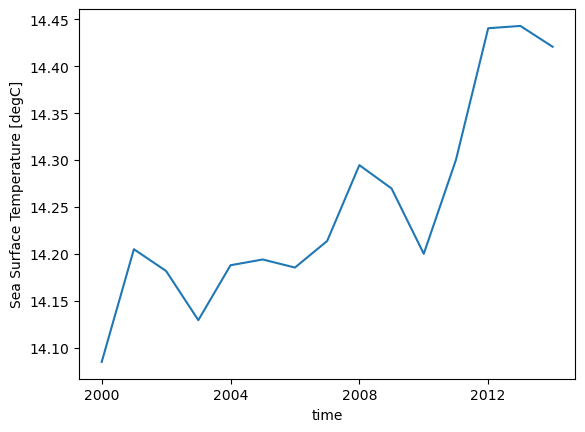

In [8]:
# calculate the global mean of the resampled data
annual_mean = tos_yearly.mean()
annual_mean_global = annual_mean.mean(dim=["lat", "lon"])
annual_mean_global.plot()

In [11]:
#Moving Average
# calculate the running mean
tos_m_avg = ds.tos.rolling(time=6, center=True).mean()
tos_m_avg

<xarray.DataArray 'tos' (time: 180, lat: 180, lon: 360)> Size: 47MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(180, 180, 360), dtype=float32)
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

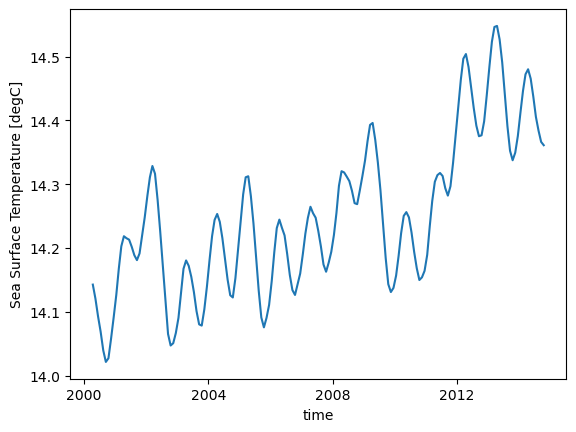

In [12]:
# calculate the global average of the running mean
tos_m_avg_global = tos_m_avg.mean(dim=["lat", "lon"])
tos_m_avg_global.plot()

In [13]:
#Coarsening the Data
coarsen_data = ds.coarsen(time= 4,lat=len(ds.lat),lon=len(ds.lon)).mean()
coarsen_data

<xarray.Dataset> Size: 1kB
Dimensions:    (time: 45, d2: 2, lat: 1, lon: 1)
Coordinates:
  * time       (time) object 360B 2000-03-01 00:00:00 ... 2014-10-30 18:00:00
  * lat        (lat) float64 8B 0.0
  * lon        (lon) float64 8B 180.0
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 720B 2000-02-15 00:00:00 ... 2014-11-16 00:0...
    lat_bnds   (lat, d2) float64 16B -0.5 0.5
    lon_bnds   (lon, d2) float64 16B 179.5 180.5
    tos        (time, lat, lon) float32 180B 14.21 14.06 13.99 ... 14.41 14.3
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

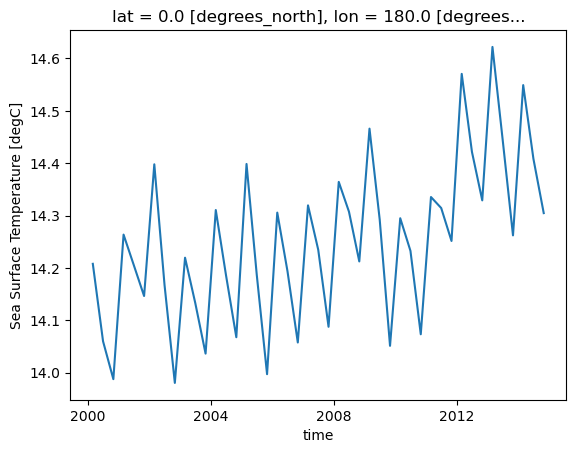

In [14]:
coarsen_data.tos.plot()

In [16]:
#Compare the Resampling Methods
original_global = ds.mean(dim=["lat", "lon"])

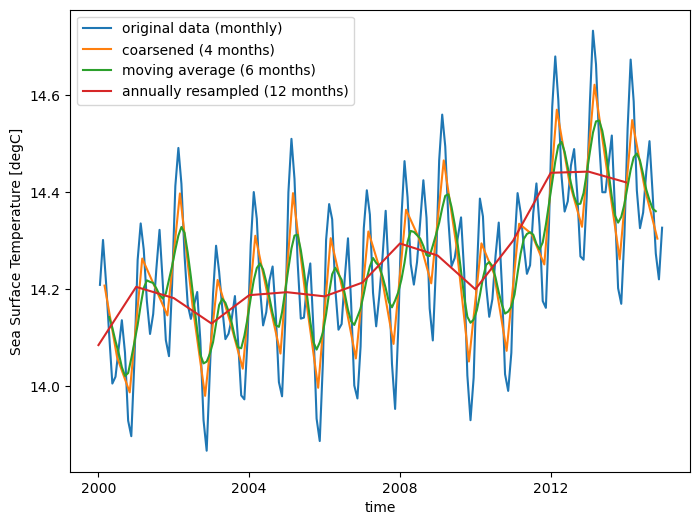

In [21]:
original_global.tos.plot(size=6)
coarsen_data.tos.plot()
tos_m_avg_global.plot()
annual_mean_global.plot()


plt.legend(
    [
        "original data (monthly)",
        "coarsened (4 months)",
        "moving average (6 months)",
        "annually resampled (12 months)",
    ]
)